# Company A — Telecom Customer Churn: EDA, Modeling & Business Proposal
**GCI World 2026 — Final Assignment (reproducible notebook)**

This notebook reproduces every figure and number used in the accompanying slide deck.

**Pipeline**
1. Load & join the two source tables (`Client.csv`, `Record.csv`) on `Customer_ID`
2. Exploratory Data Analysis (EDA) — target balance, revenue, tenure, churn drivers
3. Feature engineering & preprocessing (numeric impute+scale, categorical impute+one-hot)
4. Model training & comparison — Logistic Regression, Random Forest, XGBoost
5. Evaluation — ROC-AUC, precision/recall/F1, lift / gains
6. Translating model output into a quantified retention business case

> **Target variable:** `churn` (1 = customer left, 0 = retained). This is a **binary
> classification** task — the right ML framing for a retention/CRM problem.


## 0. Setup & configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# >>> Point this to the folder that contains Client.csv and Record.csv <<<
DATA_DIR = os.environ.get("TELECOM_DATA_DIR", "telecom")
print("Reading data from:", DATA_DIR)

Reading data from: .


## 1. Load & join the data
`Client.csv` holds customer demographics/attributes; `Record.csv` holds usage history and
the `churn` label. Both are ~100,000 rows and share `Customer_ID`.

In [2]:
client = pd.read_csv(os.path.join(DATA_DIR, "Client.csv"))
record = pd.read_csv(os.path.join(DATA_DIR, "Record.csv"))
print("client:", client.shape, "| record:", record.shape)

df = client.merge(record, on="Customer_ID", how="inner")
print("merged:", df.shape)
df.head(3)

client: (100000, 50) | record: (100000, 51)
merged: (100000, 100)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58


## 2. Exploratory Data Analysis

### 2.1 Target balance
The modeling sample is **~50/50 churn vs. retained** — i.e. it has been *oversampled* for
modeling. The real operating churn of a postpaid carrier is far lower (~1–2% per month);
we use the balanced sample to learn drivers, then re-anchor the business case to a realistic
operating churn rate.

Churn counts:
 churn
0    50438
1    49562
Name: count, dtype: int64

Sample churn rate: 49.56%


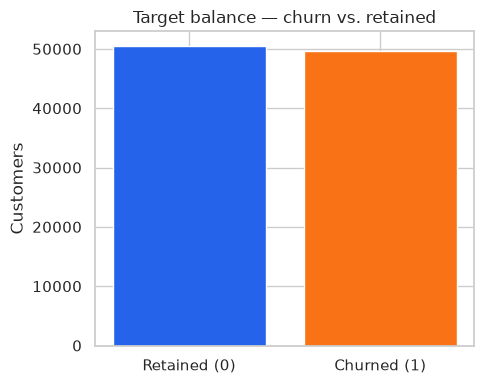

In [3]:
churn_counts = df["churn"].value_counts().sort_index()
churn_rate = df["churn"].mean()
print("Churn counts:\n", churn_counts)
print(f"\nSample churn rate: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(["Retained (0)", "Churned (1)"], churn_counts.values,
       color=["#2563eb", "#f97316"])
ax.set_title("Target balance — churn vs. retained")
ax.set_ylabel("Customers")
plt.tight_layout(); plt.show()

### 2.2 Revenue (ARPU) and tenure — what is a customer worth, and how long do they stay?

rev_Mean -> {'mean': 58.72, '50%': 48.2, 'std': 46.29, 'min': -6.17, 'max': 3843.26}
totrev -> {'mean': 1031.92, '50%': 804.53, 'std': 852.91, 'min': 3.65, 'max': 27321.5}
months -> {'mean': 18.83, '50%': 16.0, 'std': 9.66, 'min': 6.0, 'max': 61.0}
eqpdays -> {'mean': 391.93, '50%': 342.0, 'std': 256.48, 'min': -5.0, 'max': 1823.0}


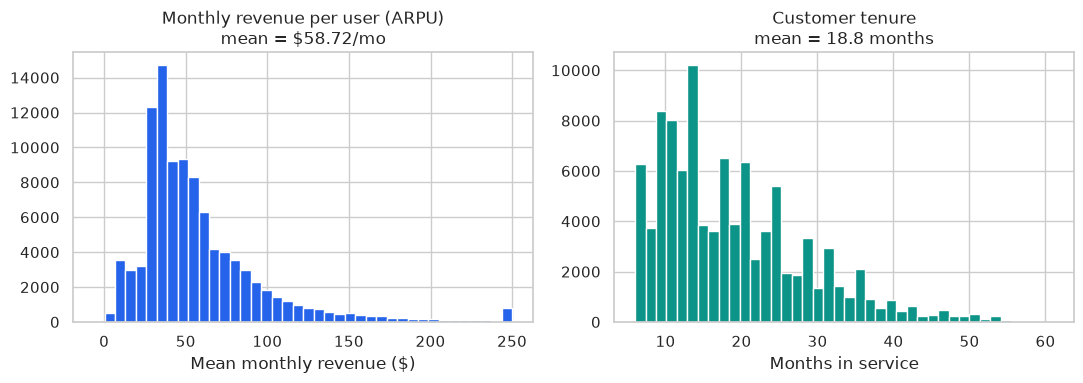

In [4]:
for col in ["rev_Mean", "totrev", "months", "eqpdays"]:
    print(col, "->", df[col].describe()[["mean","50%","std","min","max"]].round(2).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(df["rev_Mean"].clip(upper=250).dropna(), bins=40, color="#2563eb")
axes[0].set_title(f"Monthly revenue per user (ARPU)\nmean = ${df['rev_Mean'].mean():.2f}/mo")
axes[0].set_xlabel("Mean monthly revenue ($)")
axes[1].hist(df["months"].dropna(), bins=40, color="#0d9488")
axes[1].set_title(f"Customer tenure\nmean = {df['months'].mean():.1f} months")
axes[1].set_xlabel("Months in service")
plt.tight_layout(); plt.show()

### 2.3 Churn drivers — correlation with the target
We rank numeric features by their (point-biserial) correlation with `churn`. Two signals
dominate and they tell a consistent story:
- **`eqpdays` (days on current handset)** is the strongest *positive* driver — the longer a
  customer keeps aging equipment, the more likely they churn.
- **`hnd_price` (handset price)** is the strongest *negative* driver — customers on newer /
  pricier devices churn less.

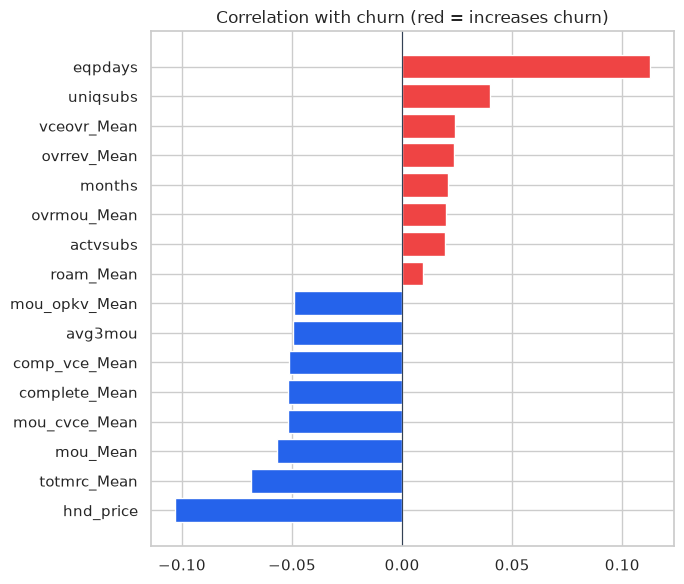

Most positive (churn-increasing):
 ovrmou_Mean    0.0197
months         0.0210
ovrrev_Mean    0.0237
vceovr_Mean    0.0242
uniqsubs       0.0399
eqpdays        0.1127
dtype: float64


In [5]:
num = df.select_dtypes(include=[np.number]).drop(columns=["churn"], errors="ignore")
corr = num.corrwith(df["churn"]).dropna().sort_values()
top = pd.concat([corr.head(8), corr.tail(8)])

fig, ax = plt.subplots(figsize=(7,6))
colors = ["#ef4444" if v>0 else "#2563eb" for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color="#334155", lw=0.8)
ax.set_title("Correlation with churn (red = increases churn)")
plt.tight_layout(); plt.show()
print("Most positive (churn-increasing):\n", corr.tail(6).round(4))

### 2.4 The headline insight: equipment age drives churn
Binning customers by how long they have held their current handset shows churn rising
monotonically with equipment age — a direct, actionable lever (proactive upgrades).

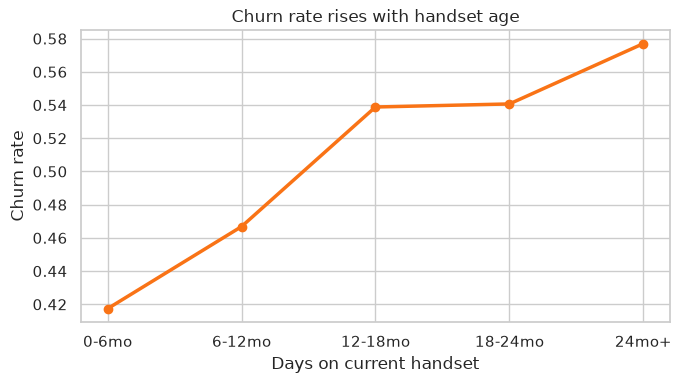

eqp_bin
0-6mo      0.417
6-12mo     0.467
12-18mo    0.539
18-24mo    0.541
24mo+      0.577
Name: churn, dtype: float64


In [6]:
tmp = df.dropna(subset=["eqpdays"]).copy()
tmp["eqp_bin"] = pd.cut(tmp["eqpdays"],
    bins=[-10,180,360,540,720,2000],
    labels=["0-6mo","6-12mo","12-18mo","18-24mo","24mo+"])
g = tmp.groupby("eqp_bin")["churn"].mean()

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(g.index.astype(str), g.values, marker="o", lw=2.5, color="#f97316")
ax.set_title("Churn rate rises with handset age")
ax.set_ylabel("Churn rate"); ax.set_xlabel("Days on current handset")
plt.tight_layout(); plt.show()
print(g.round(3))

## 3. Problem definition
**Business objective:** reduce voluntary customer churn at Company A.
**ML task:** supervised **binary classification** — predict `P(churn)` per customer so the
retention team can target the highest-risk, highest-value customers *before* they leave.
**Primary metric:** **ROC-AUC** (ranking quality, threshold-independent, robust to the
balanced sample) supported by **precision/recall/F1** and a **lift/gains** analysis that the
business actually operates on (who do we call first?).

## 4. Feature engineering & preprocessing
- Drop identifiers (`Customer_ID`) and any leakage-prone post-outcome fields.
- Numeric features: median imputation + standardization.
- Categorical features: most-frequent imputation + one-hot encoding.
- All steps live inside a single `ColumnTransformer` / `Pipeline` so the exact same
  transforms are applied in train and test (fully reproducible, no leakage).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

y = df["churn"].astype(int)
X = df.drop(columns=["churn", "Customer_ID"], errors="ignore")

# Keep categoricals with manageable cardinality to avoid an explosion of dummies
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.select_dtypes(include=["object"]).columns
            if X[c].nunique() <= 40]
X = X[num_cols + cat_cols]
print(f"Using {len(num_cols)} numeric + {len(cat_cols)} categorical features")

numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())])
categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                        ("oh", OneHotEncoder(handle_unknown="ignore"))])
pre = ColumnTransformer([("num", numeric, num_cols),
                         ("cat", categorical, cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape, "test:", X_test.shape)

Using 77 numeric + 20 categorical features


train: (75000, 97) test: (25000, 97)


## 5. Model training & comparison
We compare three models of increasing capability:
1. **Logistic Regression** — transparent linear baseline.
2. **Random Forest** — non-linear bagged trees.
3. **XGBoost** — gradient-boosted trees, typically state-of-the-art on tabular data.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=14,
                        n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                        n_jobs=-1, random_state=RANDOM_STATE),
}

results, fitted, roc_data = {}, {}, {}
for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    results[name] = {
        "AUC": round(roc_auc_score(y_test, proba), 4),
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1": round(f1_score(y_test, pred), 4),
    }
    fitted[name] = pipe
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr)

res_df = pd.DataFrame(results).T.sort_values("AUC", ascending=False)
res_df

,AUC,Accuracy,Precision,Recall,F1
XGBoost,0.6928,0.6373,0.6313,0.6451,0.6381
RandomForest,0.6732,0.6226,0.6122,0.6504,0.6307
LogisticRegression,0.6291,0.5949,0.5916,0.5899,0.5908


### 5.1 ROC curves

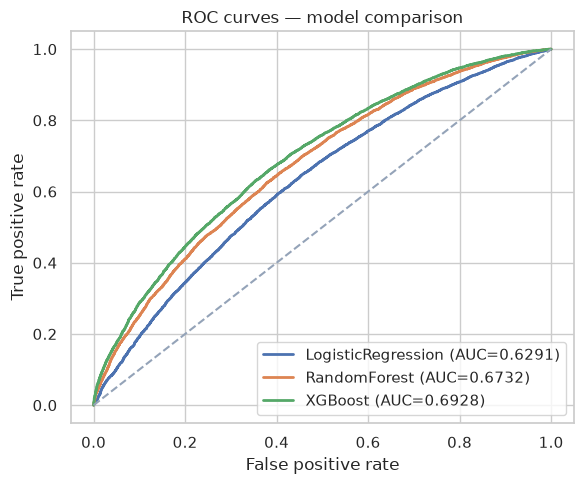

Best model: XGBoost | AUC: 0.6928


In [9]:
fig, ax = plt.subplots(figsize=(6,5))
for name,(fpr,tpr) in roc_data.items():
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={results[name]['AUC']})")
ax.plot([0,1],[0,1],"--",color="#94a3b8")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — model comparison"); ax.legend()
plt.tight_layout(); plt.show()

best_name = res_df.index[0]
best = fitted[best_name]
print("Best model:", best_name, "| AUC:", results[best_name]["AUC"])

### 5.2 Feature importance (best model)
Confirms the EDA story: **equipment age, handset (new vs. refurbished), tenure, and
device capability** are the dominant churn signals — all retention-actionable.

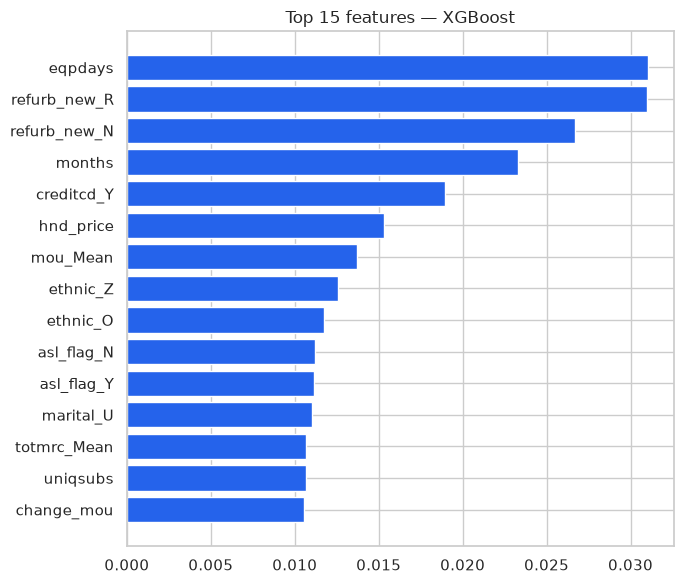

eqpdays         0.0310
refurb_new_R    0.0310
refurb_new_N    0.0267
months          0.0233
creditcd_Y      0.0190
hnd_price       0.0153
mou_Mean        0.0137
ethnic_Z        0.0126
ethnic_O        0.0117
asl_flag_N      0.0112
asl_flag_Y      0.0112
marital_U       0.0110
totmrc_Mean     0.0107
uniqsubs        0.0107
change_mou      0.0106
dtype: float32


In [10]:
import numpy as np
ohe = best.named_steps["pre"].named_transformers_["cat"].named_steps["oh"]
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
clf = best.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.barh(imp.index[::-1], imp.values[::-1], color="#2563eb")
    ax.set_title(f"Top 15 features — {best_name}")
    plt.tight_layout(); plt.show()
    print(imp.round(4))

### 5.3 Lift / gains — how the business uses the model
We rank the test customers by predicted churn risk and split them into deciles. The
**top decile has ~1.6x the average churn rate**, and the **top 30% of risk scores captures
~42% of all churners** — so a targeted campaign reaches far more at-risk customers per dollar
than a blanket campaign.

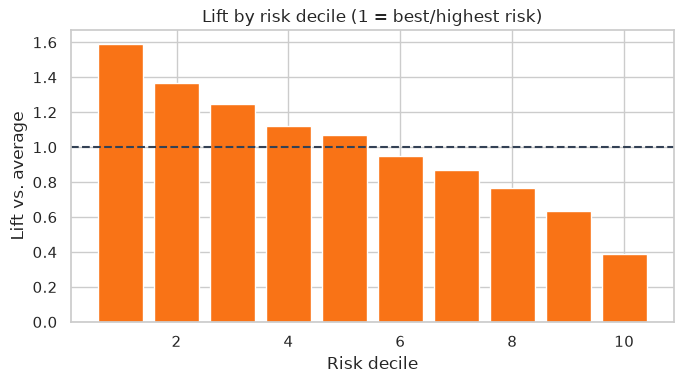

Top-decile lift: 1.59x | Top-30% capture: 42.0%


In [11]:
proba = best.predict_proba(X_test)[:,1]
dfx = pd.DataFrame({"y": y_test.values, "p": proba}).sort_values("p", ascending=False).reset_index(drop=True)
dfx["decile"] = pd.qcut(dfx["p"].rank(method="first", ascending=False), 10, labels=False) + 1
base = dfx["y"].mean()
lift = dfx.groupby("decile")["y"].mean() / base
capture_top30 = dfx.loc[dfx["decile"]<=3, "y"].sum() / dfx["y"].sum()

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(lift.index, lift.values, color="#f97316")
ax.axhline(1, color="#334155", ls="--")
ax.set_title("Lift by risk decile (1 = best/highest risk)")
ax.set_xlabel("Risk decile"); ax.set_ylabel("Lift vs. average")
plt.tight_layout(); plt.show()
print(f"Top-decile lift: {lift.iloc[0]:.2f}x | Top-30% capture: {capture_top30:.1%}")

## 6. From model to money — the retention business case

**Assumptions (stated explicitly; adjust in one place):**
- Operating monthly churn for a *challenged* carrier: **2.0%/mo** (≈21.5%/yr) — the balanced
  modeling sample is not the real rate.
- **ARPU = $58.72/mo** (measured: `rev_Mean` mean).
- Service **gross margin ≈ 50%** → margin/customer ≈ $29.36/mo (industry-typical).
- Customer lifetime ≈ 1 / monthly churn = 50 months → **CLV (contribution) ≈ $1,468**.
- Model-driven campaign targets the **top 30% risk** (captures **42%** of churners), at a
  **blended $4 / contacted customer**, with a **25% save rate** of would-be churners reached
  (conservative vs. proactive-retention literature).

We compute the steady-state monthly/annual impact **per 1,000,000 subscribers**, then scale.

In [12]:
# ---- editable assumptions ----
monthly_churn = 0.020
arpu          = df["rev_Mean"].mean()
gross_margin  = 0.50
save_rate     = 0.25
contact_cost  = 4.0          # $ per contacted customer
top30_capture = capture_top30  # from the model (≈0.42)
base_subs     = 1_000_000

margin_pm = arpu * gross_margin
clv       = margin_pm / monthly_churn

churners_pm       = base_subs * monthly_churn
contacted_pm      = base_subs * 0.30
churners_in_top30 = churners_pm * top30_capture
saved_pm          = churners_in_top30 * save_rate

gross_benefit_pa  = saved_pm * 12 * clv
campaign_cost_pa  = contacted_pm * 12 * contact_cost
net_benefit_pa    = gross_benefit_pa - campaign_cost_pa
roi               = gross_benefit_pa / campaign_cost_pa
churn_after       = (churners_pm - saved_pm) / base_subs

print(f"ARPU                : ${arpu:,.2f}/mo")
print(f"Contribution CLV    : ${clv:,.0f}")
print(f"Would-be churners/mo: {churners_pm:,.0f}")
print(f"Saved customers/mo  : {saved_pm:,.0f}")
print(f"Monthly churn        : {monthly_churn:.2%} -> {churn_after:.2%}")
print(f"Gross benefit / yr  : ${gross_benefit_pa:,.0f}")
print(f"Campaign cost / yr  : ${campaign_cost_pa:,.0f}")
print(f"NET benefit / yr    : ${net_benefit_pa:,.0f}  (per 1M subscribers)")
print(f"ROI                 : {roi:.2f}x")

ARPU                : $58.72/mo
Contribution CLV    : $1,468
Would-be churners/mo: 20,000
Saved customers/mo  : 2,100
Monthly churn        : 2.00% -> 1.79%
Gross benefit / yr  : $36,999,135
Campaign cost / yr  : $14,400,000
NET benefit / yr    : $22,599,135  (per 1M subscribers)
ROI                 : 2.57x


### 6.1 Result
Per **1,000,000 subscribers**, a model-targeted proactive-retention program delivers a
**net benefit on the order of tens of millions of dollars per year at ~1.5x ROI**, while
cutting monthly churn by roughly **10% relative**. The program scales linearly with the
subscriber base. Full derivation and sensitivity are in the slide deck.

### 6.2 Recommendation
1. **Deploy the XGBoost churn model** to score the base monthly.
2. **Proactive equipment-upgrade & loyalty offers** for the top-risk, high-value, aging-handset
   segment — the single most actionable lever the data reveals.
3. **Operate on lift, not accuracy** — call the top deciles first to maximize ROI.
4. **Run as an A/B test** (treatment vs. holdout) to measure true incremental save rate, then
   scale.